**📌 Problem**

Predict house prices using structured data.

**Why it’s valuable:** Shows regression, feature engineering, cross-validation and error reduction.


In [45]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.chdir('/content/drive/My Drive/ml-portfolio/Project2')

Mounted at /content/drive


In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [47]:
df=pd.read_csv("train.csv")

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Shape: 1460 rows × 81 columns


In [48]:
print('Column descriptions:')
col_desc = {
    'SalePrice': "the property's sale price in dollars. This is the target variable that you're trying to predict.",
    'MSSubClass': 'The building class',
    'MSZoning': 'The general zoning classification',
    'LotFrontage': 'Linear feet of street connected to property',
    'LotArea': 'Lot size in square feet',
    'Street': 'Type of road access',
    'Alley': 'Type of alley access',
    'LotShape': 'General shape of property',
    'LandContour': 'Flatness of the property',
    'Utilities': 'Type of utilities available',
    'LotConfig': 'Lot configuration',
    'LandSlope': 'Slope of property',
    'Neighborhood': 'Physical locations within Ames city limits',
    'Condition1': 'Proximity to main road or railroad',
    'Condition2': 'Proximity to main road or railroad (if a second is present)',
    'BldgType': 'Type of dwelling',
    'HouseStyle': 'Style of dwelling',
    'OverallQual': 'Overall material and finish quality',
    'OverallCond': 'Overall condition rating',
    'YearBuilt': 'Original construction date',
    'YearRemodAdd': 'Remodel date',
    'RoofStyle': 'Type of roof',
    'RoofMatl': 'Roof material',
    'Exterior1st': 'Exterior covering on house',
    'Exterior2nd': 'Exterior covering on house (if more than one material)',
    'MasVnrType': 'Masonry veneer type',
    'MasVnrArea': 'Masonry veneer area in square feet',
    'ExterQual': 'Exterior material quality',
    'ExterCond': 'Present condition of the material on the exterior',
    'Foundation': 'Type of foundation',
    'BsmtQual': 'Height of the basement',
    'BsmtCond': 'General condition of the basement',
    'BsmtExposure': 'Walkout or garden level basement walls',
    'BsmtFinType1': 'Quality of basement finished area',
    'BsmtFinSF1': 'Type 1 finished square feet',
    'BsmtFinType2': 'Quality of second finished area (if present)',
    'BsmtFinSF2': 'Type 2 finished square feet',
    'BsmtUnfSF': 'Unfinished square feet of basement area',
    'TotalBsmtSF': 'Total square feet of basement area',
    'Heating': 'Type of heating',
    'HeatingQC': 'Heating quality and condition',
    'CentralAir': 'Central air conditioning',
    'Electrical': 'Electrical system',
    '1stFlrSF': 'First Floor square feet',
    '2ndFlrSF': 'Second floor square feet',
    'LowQualFinSF': 'Low quality finished square feet (all floors)',
    'GrLivArea': 'Above grade (ground) living area square feet',
    'BsmtFullBath': 'Basement full bathrooms',
    'BsmtHalfBath': 'Basement half bathrooms',
    'FullBath': 'Full bathrooms above grade',
    'HalfBath': 'Half baths above grade',
    'Bedroom': 'Number of bedrooms above basement level',
    'Kitchen': 'Number of kitchens',
    'KitchenQual': 'Kitchen quality',
    'TotRmsAbvGrd': 'Total rooms above grade (does not include bathrooms)',
    'Functional': 'Home functionality rating',
    'Fireplaces': 'Number of fireplaces',
    'FireplaceQu': 'Fireplace quality',
    'GarageType': 'Garage location',
    'GarageYrBlt': 'Year garage was built',
    'GarageFinish': 'Interior finish of the garage',
    'GarageCars': 'Size of garage in car capacity',
    'GarageArea': 'Size of garage in square feet',
    'GarageQual': 'Garage quality',
    'GarageCond': 'Garage condition',
    'PavedDrive': 'Paved driveway',
    'WoodDeckSF': 'Wood deck area in square feet',
    'OpenPorchSF': 'Open porch area in square feet',
    'EnclosedPorch': 'Enclosed porch area in square feet',
    '3SsnPorch': 'Three season porch area in square feet',
    'ScreenPorch': 'Screen porch area in square feet',
    'PoolArea': 'Pool area in square feet',
    'PoolQC': 'Pool quality',
    'Fence': 'Fence quality',
    'MiscFeature': 'Miscellaneous feature not covered in other categories',
    'MiscVal': '$Value of miscellaneous feature',
    'MoSold': 'Month Sold',
    'YrSold': 'Year Sold',
    'SaleType': 'Type of sale',
    'SaleCondition': 'Condition of sale'
}
for col, desc in col_desc.items():
    print(f'  {col:25s}: {desc}')

df.head()

Column descriptions:
  SalePrice                : the property's sale price in dollars. This is the target variable that you're trying to predict.
  MSSubClass               : The building class
  MSZoning                 : The general zoning classification
  LotFrontage              : Linear feet of street connected to property
  LotArea                  : Lot size in square feet
  Street                   : Type of road access
  Alley                    : Type of alley access
  LotShape                 : General shape of property
  LandContour              : Flatness of the property
  Utilities                : Type of utilities available
  LotConfig                : Lot configuration
  LandSlope                : Slope of property
  Neighborhood             : Physical locations within Ames city limits
  Condition1               : Proximity to main road or railroad
  Condition2               : Proximity to main road or railroad (if a second is present)
  BldgType                 : Typ

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#Exploratory Data Analysis (EDA)

In [49]:
df.shape

(1460, 81)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [51]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [52]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


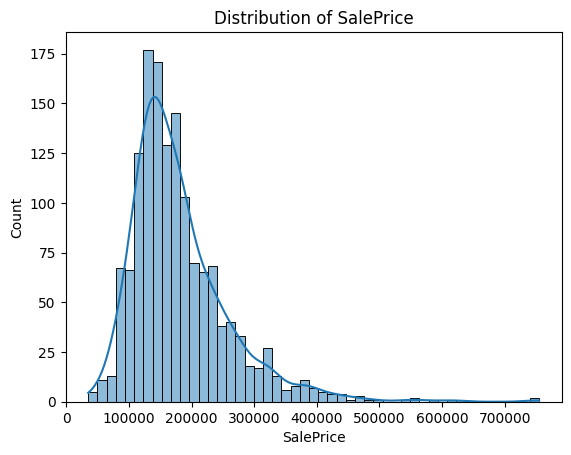

In [53]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

**House prices are right-skewed.**

In [54]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


<Axes: >

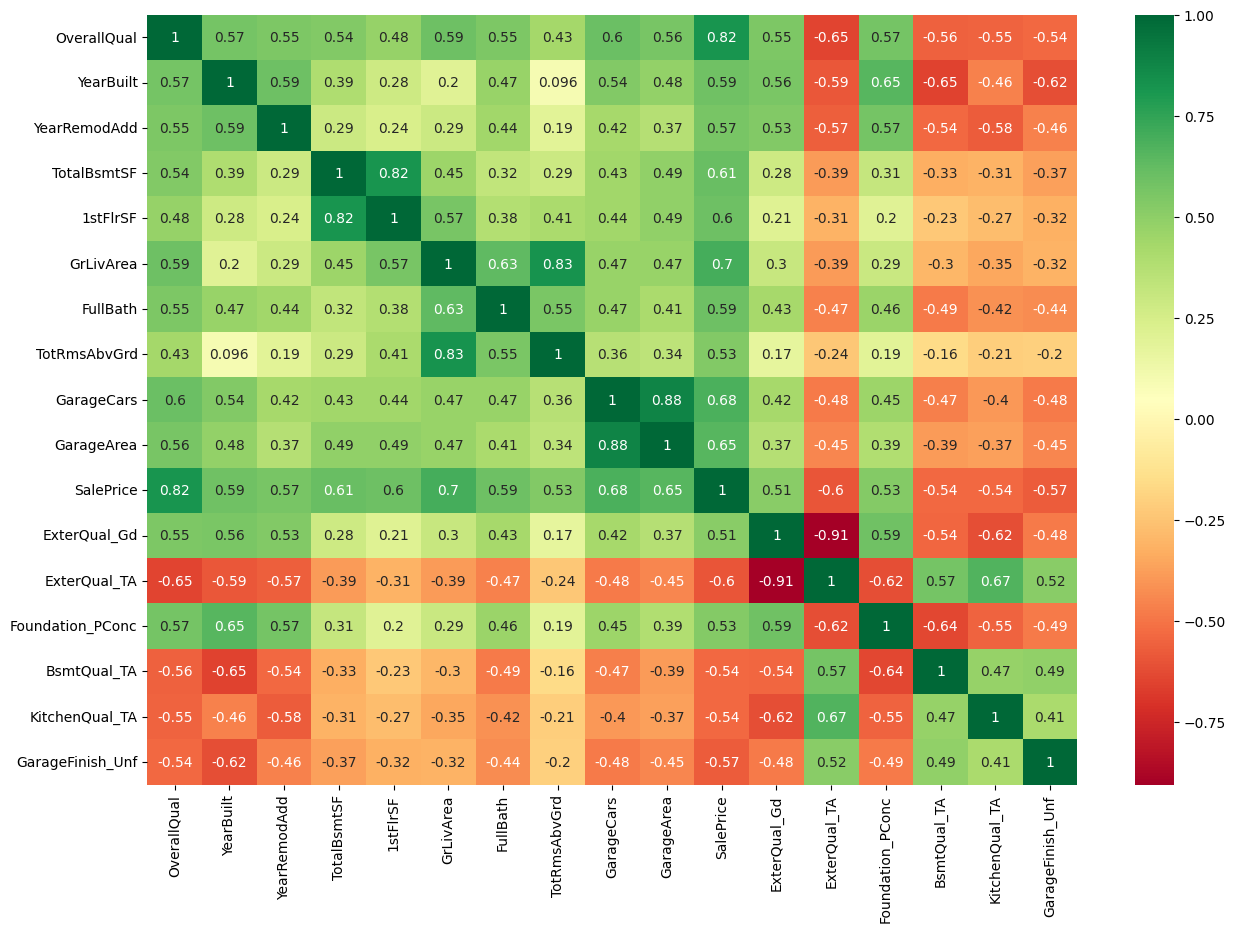

In [72]:
# Select top 10 features correlated with SalePrice
plt.figure(figsize=(15, 10))
corr_matrix=df.corr(numeric_only=True)
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn")

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

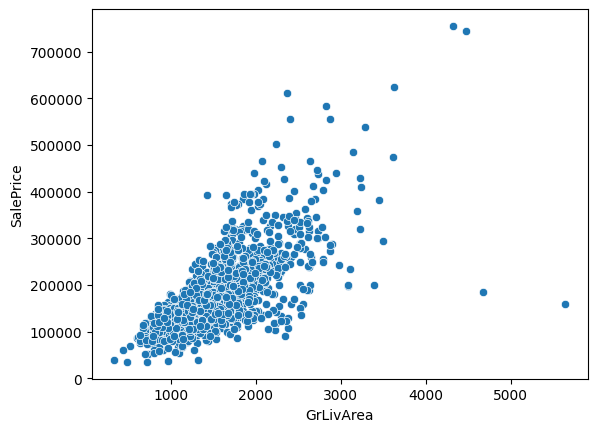

In [56]:
import seaborn as sns
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

In [57]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

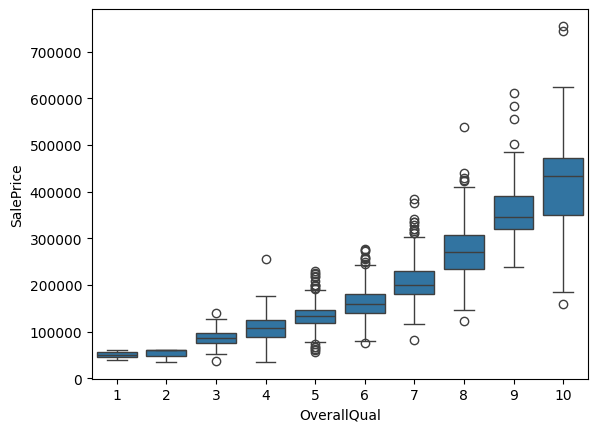

In [58]:
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])

#Data Preprocessing

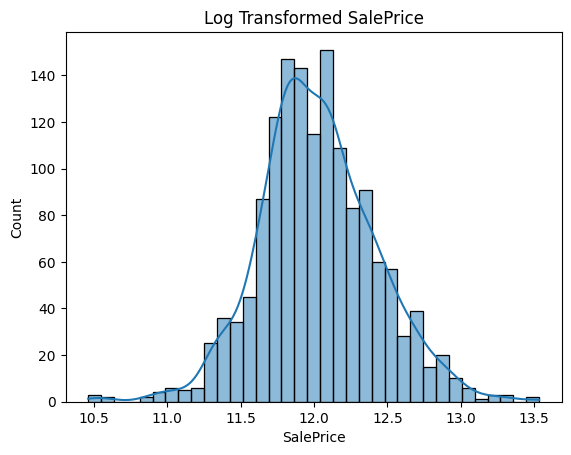

In [59]:
df['SalePrice']=np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice'], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

**Reduced skewness**

In [60]:
# Drop columns with too many missing values
df = df.dropna(thresh=len(df)*0.7, axis=1)

In [61]:
# Fill numeric missing with median
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_275/216449633.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [62]:
# Fill categorical missing with mode
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_275/2799029657.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Median is robust to outliers

Mode works for categorical

We avoid deleting too much data

#Feature Engineering

In [63]:
df = pd.get_dummies(df, drop_first=True)

Models require numeric input.

One-hot encoding converts categories to numbers.

#Model Training

##Prepare Data

In [64]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear models assume comparable feature scale.

Tree models don’t require scaling.

##Model 1: Linear Regression

In [66]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

Linear Regression RMSE: 0.2080125234967107
Linear Regression R2: 0.7681315004082618


##Model 2: Ridge Regression

In [67]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge RMSE: 0.19879168824866816
Ridge R2: 0.7882325386326231


Ridge Regression:

Adds L2 regularization.

Reduces overfitting.

##Model 3: Lasso Regression

In [68]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso RMSE: 0.17089056883809636
Lasso R2: 0.8435055366320228


Lasso Regression:

Performs feature selection.

Shrinks some coefficients to zero.

##Model 4: Random Forest

In [69]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.14723649588083043
Random Forest R2: 0.8838300687265099


#Evaluation - Compare Models

In [70]:
models = {
    "Linear": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled if name != "RandomForest" else X_train,
        y_train,
        scoring="r2",
        cv=5
    )
    print(name, "CV Mean R2:", scores.mean())

Linear CV Mean R2: 0.7300295638789791
Ridge CV Mean R2: 0.7501645919747216
Lasso CV Mean R2: 0.8003763725061497
Random Forest CV Mean R2: 0.8582308885015824


##Feature Importance (Random Forest)

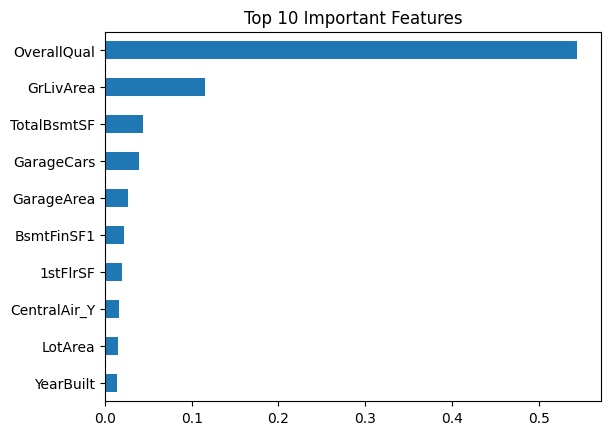

In [71]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

#We have seen so far:

* Regression metrics (RMSE, R²)

* Log transformation

* Regularization (Ridge vs Lasso)

* Feature selection effect

* Tree vs Linear model comparison

* Cross-validation for regression

* Feature importance interpretation

#Conclusion

**Observation1:**

Linear → 0.768

Ridge → 0.788

Lasso → 0.843

That’s a BIG jump.

***This tells us:***

* Plain Linear Regression was overfitting or suffering from multicollinearity.

* Regularization improved generalization.

* Lasso improved more than Ridge.

Because Lasso performs **feature selection.**

House dataset has many correlated features.
Lasso likely removed noisy ones.

**Observation2:**

Random Forest Dominates

R² = 0.884

CV = 0.859

Small drop (~0.025). ***Means:***

✔ Good generalization

✔ Low variance

✔ Captures non-linear relationships

This dataset contains strong non-linear patterns.

Trees handle that better than linear models.

**Observation3:**

CV vs Test Alignment

CV scores are aligned with test scores.

***Check differences:***

Linear:
0.768 vs 0.730 → small gap

Ridge:
0.788 vs 0.750 → small gap

Lasso:
0.843 vs 0.800 → moderate gap but acceptable

Random Forest:
0.884 vs 0.859 → small gap

***This indicates:***

No serious overfitting.

Good pipeline discipline.